# CICIDS2017 — RF + XGBoost Ensemble Training
### 46 features, 5 classes: Normal Traffic, DoS, DDoS, Brute Force, Port Scan
Run on Kaggle with `cicids2017_preprocessed.csv` uploaded as a dataset.

In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Paths — update if running locally
DATA_PATH   = r'D:\Academic\ML\ModelTraining\Preprocessing\cicids2017_preprocessed.csv'
MODEL_OUT   = r'D:\Academic\ML\ModelTraining\newOutput\ensemble_model.pkl'
SCALER_OUT  = r'D:\Academic\ML\ModelTraining\newOutput\scaler.pkl'
ENCODER_OUT = r'D:\Academic\ML\ModelTraining\newOutput\label_encoder.pkl'

RANDOM_STATE = 42

## 1. Load Data

In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['Attack Type'].value_counts())
print(f'\nFeatures: {df.shape[1] - 1}')

Shape: (2515963, 47)

Class distribution:
Attack Type
Normal Traffic    2094458
DoS                193647
DDoS               128014
Port Scan           90694
Brute Force          9150
Name: count, dtype: int64

Features: 46


## 2. Feature / Label Split

In [27]:
feature_cols = [c for c in df.columns if c != 'Attack Type']
DROP_COLS = [
    'Destination Port',
    'Bwd Packet Length Min',
    'Packet Length Variance',
    'Total Length of Bwd Packets',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
]
feature_cols = [c for c in feature_cols if c not in DROP_COLS]
print(f'Feature columns ({len(feature_cols)}):')
for i, c in enumerate(feature_cols):
    print(f'  {i+1:2d}. {c}')

X = df[feature_cols].values
y_raw = df['Attack Type'].values

Feature columns (40):
   1. Flow Duration
   2. Total Fwd Packets
   3. Total Backward Packets
   4. Total Length of Fwd Packets
   5. Fwd Packet Length Max
   6. Fwd Packet Length Min
   7. Fwd Packet Length Mean
   8. Fwd Packet Length Std
   9. Bwd Packet Length Max
  10. Bwd Packet Length Mean
  11. Bwd Packet Length Std
  12. Flow Bytes/s
  13. Flow Packets/s
  14. Flow IAT Mean
  15. Flow IAT Std
  16. Flow IAT Max
  17. Flow IAT Min
  18. Fwd IAT Std
  19. Fwd IAT Min
  20. Bwd IAT Total
  21. Bwd IAT Max
  22. Bwd IAT Min
  23. Fwd Header Length
  24. Bwd Header Length
  25. Bwd Packets/s
  26. Min Packet Length
  27. Max Packet Length
  28. Packet Length Mean
  29. Packet Length Std
  30. FIN Flag Count
  31. PSH Flag Count
  32. ACK Flag Count
  33. Init_Win_bytes_forward
  34. Init_Win_bytes_backward
  35. act_data_pkt_fwd
  36. min_seg_size_forward
  37. Active Mean
  38. Active Max
  39. Active Min
  40. Idle Mean


## 3. Label Encoding

In [28]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f'Classes: {list(le.classes_)}')
print(f'Encoded: {list(range(len(le.classes_)))}')

joblib.dump(le, ENCODER_OUT)
print(f'Saved: {ENCODER_OUT}')

Classes: ['Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scan']
Encoded: [0, 1, 2, 3, 4]
Saved: D:\Academic\ML\ModelTraining\newOutput\label_encoder.pkl


## 4. Train / Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Verify stratification
unique, counts = np.unique(y_train, return_counts=True)
print('\nTrain class distribution:')
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls}: {cnt:,}')

Train: (2012770, 40), Test: (503193, 40)

Train class distribution:
  Brute Force: 7,320
  DDoS: 102,411
  DoS: 154,918
  Normal Traffic: 1,675,566
  Port Scan: 72,555


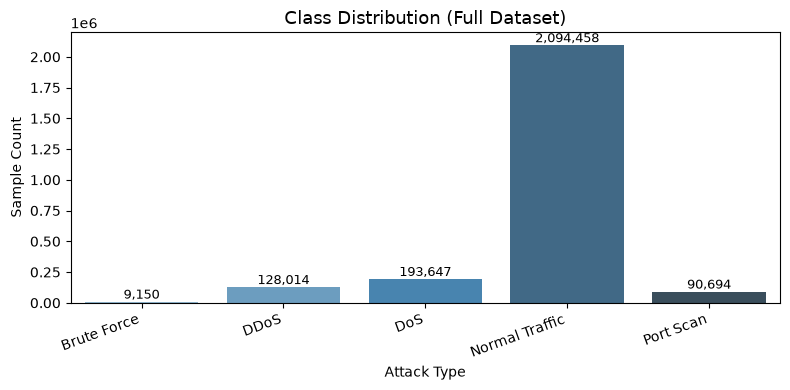

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
class_counts = pd.Series(
    [(y_train == i).sum() + (y_test == i).sum() for i in range(len(le.classes_))],
    index=le.classes_
)
sns.barplot(x=class_counts.index, y=class_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Class Distribution (Full Dataset)', fontsize=13)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Sample Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Scaling

In [31]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, SCALER_OUT)
print(f'Saved: {SCALER_OUT}')

Saved: D:\Academic\ML\ModelTraining\newOutput\scaler.pkl


## 6. Compute Sample Weights
Handles class imbalance for both RF and XGBoost.

In [32]:
# sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
# print(f'Sample weight range: {sample_weights.min():.4f} — {sample_weights.max():.4f}')

# # Show effective weight per class
# for cls_idx, cls_name in enumerate(le.classes_):
#     mask = y_train == cls_idx
#     print(f'  {cls_name}: weight = {sample_weights[mask].mean():.4f}')

In [33]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# 1. Compute original balanced weights per class index
classes = np.unique(y_train)
balanced_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# 2. Map class index to its newly adjusted weight
# Example adjustments: Normal Traffic x 0.8 (decrease), all attack classes x 1.25 (increase)
manual_class_weights = {}
for cls_idx, cls_name in enumerate(le.classes_):
    if cls_name == 'Normal Traffic':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 0.8
    elif cls_name == 'Brute Force':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 3.0  # highest boost
    elif cls_name == 'DoS' or cls_name == 'DDoS':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 1.5  # these overlap, moderate boost
    else:
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 1.5
# 3. Compute final sample weights using your modified class weights
sample_weights = compute_sample_weight(class_weight=manual_class_weights, y=y_train)

# 4. Print results to verify
print(f'Sample weight range: {sample_weights.min():.4f} — {sample_weights.max():.4f}')
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_train == cls_idx
    print(f'  {cls_name}: weight = {sample_weights[mask].mean():.4f}')

Sample weight range: 0.1922 — 164.9811
  Brute Force: weight = 164.9811
  DDoS: weight = 5.8962
  DoS: weight = 3.8977
  Normal Traffic: weight = 0.1922
  Port Scan: weight = 8.3224


## 7. Train Random Forest

In [35]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    max_features=0.4,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train,sample_weight=sample_weights)
print('RF training complete.')

rf_train_acc = rf.score(X_train_scaled, y_train)
rf_test_acc  = rf.score(X_test_scaled,  y_test)
print(f'RF Train Accuracy: {rf_train_acc:.4f}')
print(f'RF Test  Accuracy: {rf_test_acc:.4f}')

RF training complete.
RF Train Accuracy: 0.9993
RF Test  Accuracy: 0.9992


## 8. Train XGBoost
Trained separately with sample_weight — fixes the VotingClassifier bug
where sample weights are not routed to internal estimators.

In [36]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.5,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=1
)
# Pass sample_weight directly — this is the fix for the imbalance bug
xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights,
        eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
        verbose=20)
print('XGBoost training complete.')

xgb_train_acc = xgb.score(X_train_scaled, y_train)
xgb_test_acc  = xgb.score(X_test_scaled,  y_test)
print(f'XGB Train Accuracy: {xgb_train_acc:.4f}')
print(f'XGB Test  Accuracy: {xgb_test_acc:.4f}')

[0]	validation_0-mlogloss:1.90666	validation_1-mlogloss:1.90653
[20]	validation_0-mlogloss:0.25366	validation_1-mlogloss:0.25384
[40]	validation_0-mlogloss:0.05605	validation_1-mlogloss:0.05603
[60]	validation_0-mlogloss:0.01937	validation_1-mlogloss:0.01929
[80]	validation_0-mlogloss:0.00966	validation_1-mlogloss:0.00960
[100]	validation_0-mlogloss:0.00616	validation_1-mlogloss:0.00611
[120]	validation_0-mlogloss:0.00464	validation_1-mlogloss:0.00460
[140]	validation_0-mlogloss:0.00394	validation_1-mlogloss:0.00391
[160]	validation_0-mlogloss:0.00350	validation_1-mlogloss:0.00350
[180]	validation_0-mlogloss:0.00324	validation_1-mlogloss:0.00326
[199]	validation_0-mlogloss:0.00305	validation_1-mlogloss:0.00310
XGBoost training complete.
XGB Train Accuracy: 0.9995
XGB Test  Accuracy: 0.9994


## 9. Build Soft-Voting Ensemble
Uses pre-fitted estimators — VotingClassifier is set to use them as-is.

In [37]:
from sklearn.preprocessing import LabelEncoder as SklearnLE
from sklearn.utils.multiclass import unique_labels

# Manually construct a minimal internal LabelEncoder that maps 0-4 to 0-4
internal_le = SklearnLE()
internal_le.fit(np.array(list(range(len(le.classes_)))))

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)
ensemble.estimators_ = [rf, xgb]
ensemble.le_ = internal_le
ensemble.classes_ = np.array(list(range(len(le.classes_))))
ensemble.named_estimators_ = {'rf': rf, 'xgb': xgb}

ensemble_test_acc = ensemble.score(X_test_scaled, y_test)
print(f'Ensemble Test Accuracy: {ensemble_test_acc:.4f}')

joblib.dump(ensemble, MODEL_OUT)
print(f'Saved: {MODEL_OUT}')

Ensemble Test Accuracy: 0.9995
Saved: D:\Academic\ML\ModelTraining\newOutput\ensemble_model.pkl


## 10. Classification Report

In [38]:
y_pred = ensemble.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

                precision    recall  f1-score   support

   Brute Force     0.9973    0.9973    0.9973      1830
          DDoS     0.9996    1.0000    0.9998     25603
           DoS     0.9958    0.9999    0.9978     38729
Normal Traffic     1.0000    0.9994    0.9997    418892
     Port Scan     0.9954    0.9994    0.9974     18139

      accuracy                         0.9995    503193
     macro avg     0.9976    0.9992    0.9984    503193
  weighted avg     0.9995    0.9995    0.9995    503193



In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("\nRow = True, Col = Predicted")
print(cm_df)
# DoS-DDoS off-diagonal specifically
dos_idx = list(le.classes_).index('DoS')
ddos_idx = list(le.classes_).index('DDoS')
print(f"\nDoS predicted as DDoS: {cm[dos_idx][ddos_idx]}")
print(f"DDoS predicted as DoS: {cm[ddos_idx][dos_idx]}")


Row = True, Col = Predicted
                Brute Force   DDoS    DoS  Normal Traffic  Port Scan
Brute Force            1825      0      0               5          0
DDoS                      0  25602      0               1          0
DoS                       0      0  38724               5          0
Normal Traffic            5     10    154          418639         84
Port Scan                 0      0      9               2      18128

DoS predicted as DDoS: 0
DDoS predicted as DoS: 0


## 11. Confusion Matrix

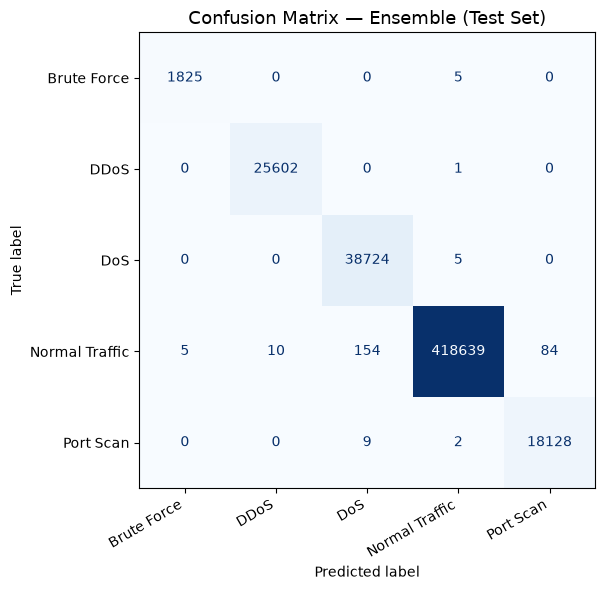

In [40]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Ensemble (Test Set)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\confusion_matrix.png', bbox_inches='tight')
plt.show()

## 12. Per-Model Comparison

In [41]:
from sklearn.metrics import f1_score

rf_pred  = rf.predict(X_test_scaled)
xgb_pred = xgb.predict(X_test_scaled)
ens_pred = y_pred

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Ensemble'],
    'Test Accuracy': [
        rf.score(X_test_scaled, y_test),
        xgb.score(X_test_scaled, y_test),
        ensemble.score(X_test_scaled, y_test)
    ],
    'Macro F1': [
        f1_score(y_test, rf_pred,  average='macro'),
        f1_score(y_test, xgb_pred, average='macro'),
        f1_score(y_test, ens_pred, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, rf_pred,  average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted'),
        f1_score(y_test, ens_pred, average='weighted')
    ]
})
print(results.to_string(index=False))

        Model  Test Accuracy  Macro F1  Weighted F1
Random Forest       0.999239  0.997713     0.999240
      XGBoost       0.999436  0.998004     0.999436
     Ensemble       0.999453  0.998391     0.999454


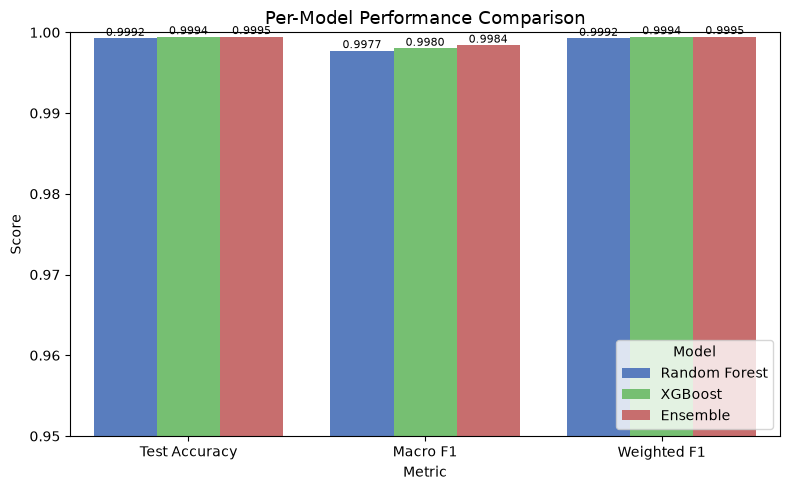

In [42]:
metrics_df = results.melt(id_vars='Model', value_vars=['Test Accuracy', 'Macro F1', 'Weighted F1'],
                           var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model',
            palette=['#4878CF', '#6ACC65', '#D65F5F'], ax=ax)
ax.set_title('Per-Model Performance Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.95, 1.0)
ax.legend(title='Model', loc='lower right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

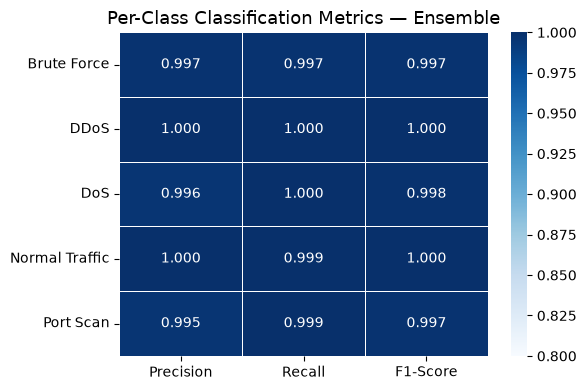

In [43]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.loc[le.classes_, ['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(report_df.astype(float), annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0.8, vmax=1.0)
ax.set_title('Per-Class Classification Metrics — Ensemble', fontsize=13)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\classification_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Feature Importance (RF)

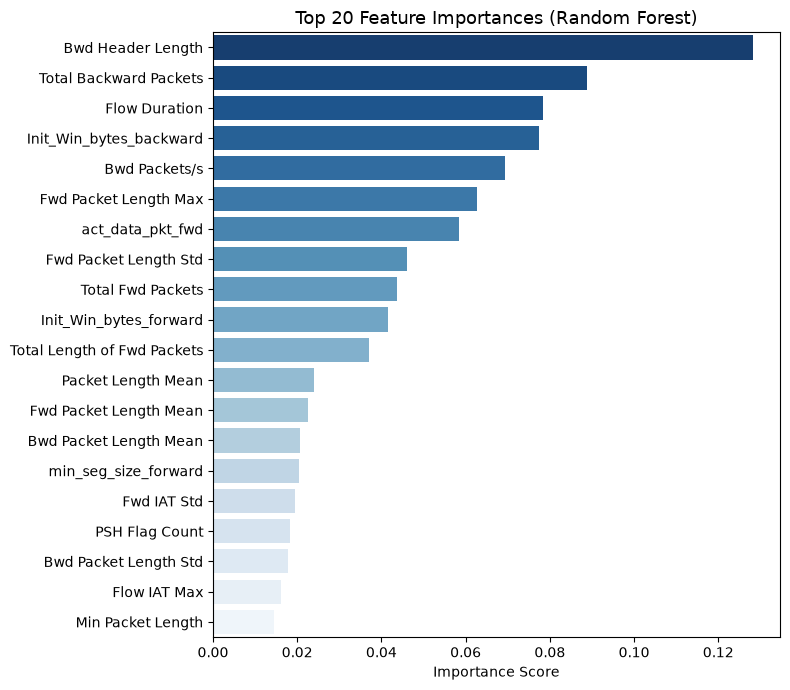

In [44]:
top_n = 20
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r', ax=ax)
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\feature_importance_top20.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
anova_top10 = [
    'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Header Length',
    'Fwd Header Length', 'Idle Mean', 'Total Fwd Packets',
    'Flow IAT Max', 'Flow Duration', 'Fwd IAT Std', 'Total Backward Packets'
]
top_n = importances.head(20).index.tolist()
overlap = [f for f in anova_top10 if f in top_n]
print(f"ANOVA top-10 features also in RF top-20: {len(overlap)}/10")
print(overlap)

ANOVA top-10 features also in RF top-20: 8/10
['Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Header Length', 'Total Fwd Packets', 'Flow IAT Max', 'Flow Duration', 'Fwd IAT Std', 'Total Backward Packets']


## 14. Verify Saved Artifacts

In [46]:
# Reload and do a quick sanity check
loaded_model   = joblib.load(MODEL_OUT)
loaded_scaler  = joblib.load(SCALER_OUT)
loaded_encoder = joblib.load(ENCODER_OUT)

# Single sample prediction
sample_raw     = X_test[0:1]
sample_scaled  = loaded_scaler.transform(sample_raw)
pred_encoded   = loaded_model.predict(sample_scaled)
pred_label     = loaded_encoder.inverse_transform(pred_encoded)
pred_proba     = loaded_model.predict_proba(sample_scaled)

print(f'Sample prediction: {pred_label[0]}')
print(f'True label:        {loaded_encoder.inverse_transform([y_test[0]])[0]}')
print(f'\nClass probabilities:')
for cls, prob in zip(loaded_encoder.classes_, pred_proba[0]):
    print(f'  {cls}: {prob:.4f}')

Sample prediction: Normal Traffic
True label:        Normal Traffic

Class probabilities:
  Brute Force: 0.0000
  DDoS: 0.0000
  DoS: 0.0000
  Normal Traffic: 1.0000
  Port Scan: 0.0000
